# Factor History Analysis

Copy `data/results_verification/factor_history.log` from the cluster to this repository (e.g., via `scp`) before running the cells below.

In [12]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
if not (repo_root / 'scripts').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib

try:
    matplotlib.use('module://matplotlib_inline.backend_inline')
except ValueError:
    matplotlib.use('nbagg')

import matplotlib.pyplot as plt

from scripts.factor_history_tools import (
    parse_factor_history,
    records_to_dataframe,
    add_absolute_capacities,
    plot_factor_trajectories,
    plot_cost_and_feasibility,
)

In [13]:
LOG_PATH = repo_root / 'data/results_verification/factor_history.log'
records = parse_factor_history(LOG_PATH)
print(f"Loaded {len(records)} records from {LOG_PATH}.")


Loaded 621 records from /Users/andreasmuhlbauer/Library/CloudStorage/OneDrive-Stanford/Research/JacobsonLab/2025LOADMATCH-PYTHON/loadmatch-python/data/results_verification/factor_history.log.


In [14]:
records_df = records_to_dataframe(records)
try:
    df = add_absolute_capacities(records_df, region="UNITED-STATES")
except FileNotFoundError:
    print("Supply file missing; falling back to multipliers only.")
    df = records_df


Supply file missing; falling back to multipliers only.


Absolute capacities unavailable (missing raw inputs); plotting multipliers instead.


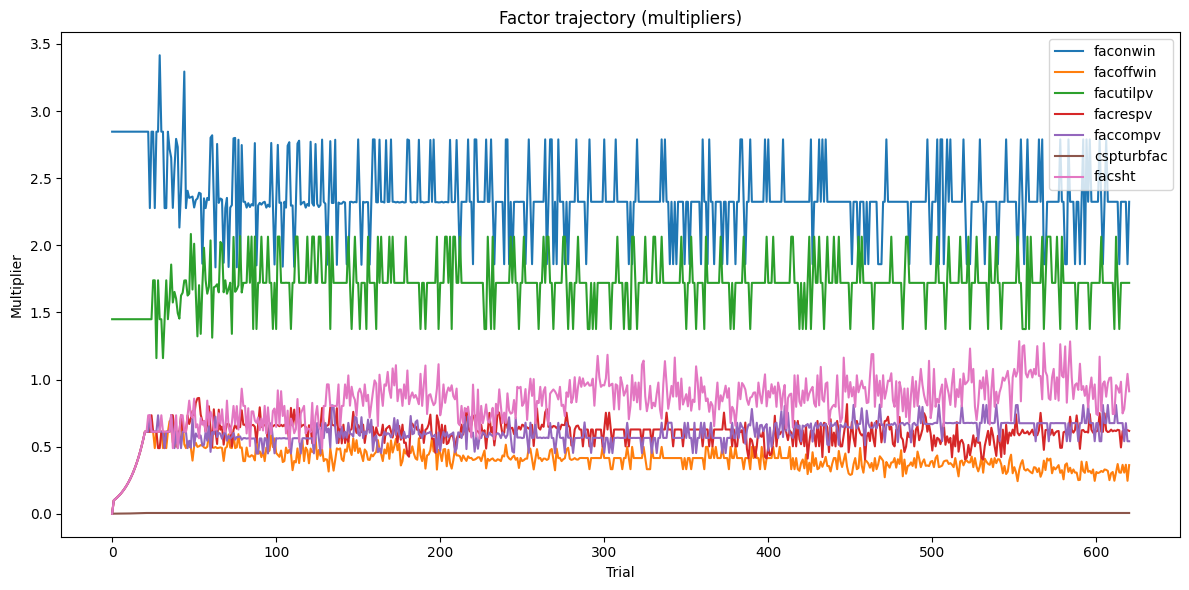

In [15]:
_ = plot_factor_trajectories(df, absolute=True)
plt.show()

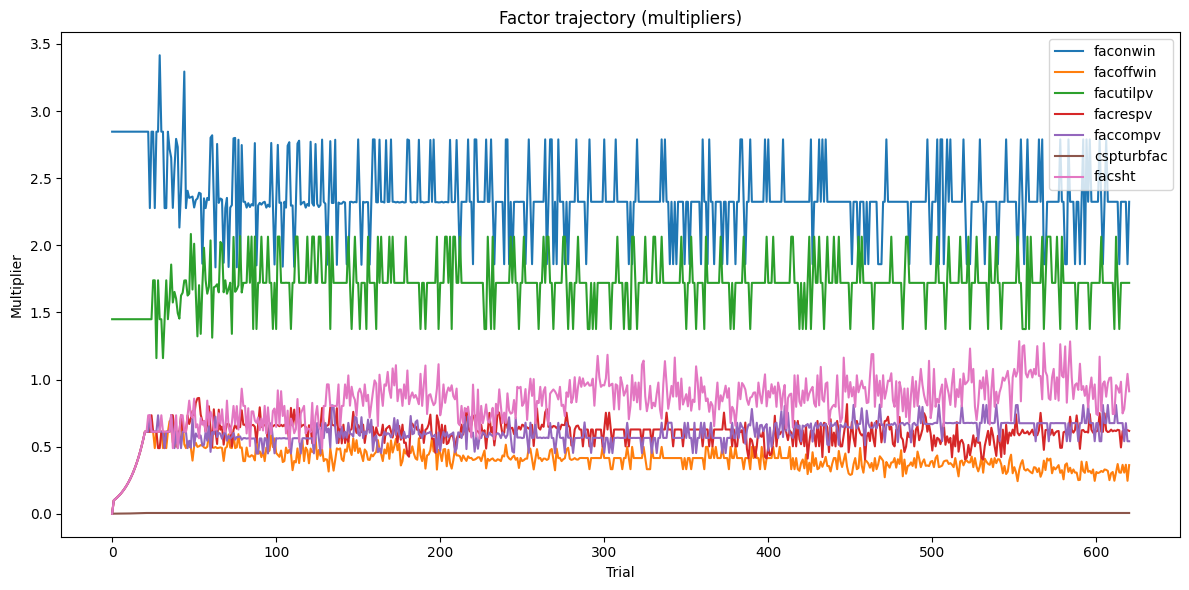

In [16]:
_ = plot_factor_trajectories(df, absolute=False)
plt.show()

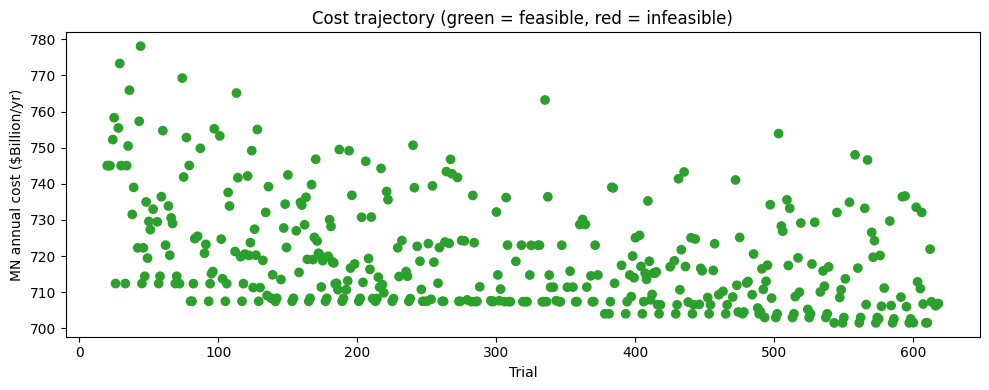

In [17]:
_ = plot_cost_and_feasibility(df)
plt.show()

## Capacity Evolution Over GA Iterations

Plot absolute capacities at the initial guess (LP), every 100th trial, and the final optimal solution as bar charts, with system cost overlaid on a secondary axis.

In [18]:
import numpy as np

# Base capacities for USA from countrystats.dat (in MW)
BASE_CAPACITIES_USA = {
    "onshore_wind": 798934.02,     # TMWONWIND
    "offshore_wind": 526241.51,    # TWOFFWIND
    "res_rooftop_pv": 701942.21,   # TMWRESPV
    "com_rooftop_pv": 701942.21,   # TMWCOMPV
    "utility_pv": 1199905.98,      # TMWUTILPV
    "csp": 1119.82,                # TMWCSPORIG (original CSP only)
    "solar_thermal": 18185.00,     # TMWSOLTH
}

# Factor to capacity mapping
FACTOR_TO_CAPACITY = {
    "faconwin": ("onshore_wind", "Onshore Wind"),
    "facoffwin": ("offshore_wind", "Offshore Wind"),
    "facutilpv": ("utility_pv", "Utility PV"),
    "facrespv": ("res_rooftop_pv", "Res. Rooftop PV"),
    "faccompv": ("com_rooftop_pv", "Com. Rooftop PV"),
    "cspturbfac": ("csp", "CSP"),
    "facsht": ("solar_thermal", "Solar Thermal"),
}

def compute_absolute_capacities_manual(row):
    """Compute absolute capacities (GW) from factors and base capacities."""
    result = {}
    for factor_col, (base_key, display_name) in FACTOR_TO_CAPACITY.items():
        factor = row.get(factor_col, 0.0)
        base_mw = BASE_CAPACITIES_USA[base_key]
        result[display_name] = factor * base_mw / 1000.0  # Convert MW to GW
    return result

# Identify which factors remained constant during GA optimization
# Check variance of each factor during GA phase (after inflate-subunity)
ga_records = [r for r in records if r.get("label", "").startswith("GA-")]
constant_factors = []
for factor_col in FACTOR_TO_CAPACITY.keys():
    values = [r.get(factor_col, 0.0) for r in ga_records]
    if len(set(round(v, 8) for v in values)) == 1:  # All same value
        constant_factors.append(factor_col)
        
print(f"Factors that remained constant during GA optimization: {constant_factors}")
print(f"  -> These will be marked as 'not optimized' in the plot")

Factors that remained constant during GA optimization: ['cspturbfac']
  -> These will be marked as 'not optimized' in the plot


In [19]:
# Select trials to plot: initial (0), every 100th trial, and find best feasible
trial_indices = [0, 100, 200, 300, 400, 500, 600]
trial_indices = [i for i in trial_indices if i < len(records)]

# Find the best feasible solution (lowest cost among feasible)
feasible_records = [(i, r) for i, r in enumerate(records) 
                    if r.get("feasible", False) and r.get("cost_mn_bil_per_year", float("inf")) < float("inf")]
if feasible_records:
    best_idx, best_record = min(feasible_records, key=lambda x: x[1]["cost_mn_bil_per_year"])
    # Add best feasible if not already in trial_indices
    if best_idx not in trial_indices:
        trial_indices.append(best_idx)

# Sort and deduplicate
trial_indices = sorted(set(trial_indices))

print(f"Plotting trials: {trial_indices}")
print(f"Best feasible solution at trial {best_idx} with cost ${best_record['cost_mn_bil_per_year']:.2f} billion/year")

Plotting trials: [0, 100, 200, 300, 400, 500, 543, 600]
Best feasible solution at trial 543 with cost $701.54 billion/year


In [20]:
# Prepare data for plotting
tech_names = list(FACTOR_TO_CAPACITY.values())
tech_display_names = [name for _, name in tech_names]
n_techs = len(tech_display_names)

# Map factor columns to display names for identifying constant ones
factor_to_display = {k: v[1] for k, v in FACTOR_TO_CAPACITY.items()}
constant_display_names = {factor_to_display[f] for f in constant_factors}

# Extract capacities and costs for selected trials
capacities_by_trial = []
costs_by_trial = []
labels_by_trial = []

for idx in trial_indices:
    rec = records[idx]
    caps = compute_absolute_capacities_manual(rec)
    capacities_by_trial.append([caps[name] for name in tech_display_names])
    
    cost = rec.get("cost_mn_bil_per_year", float("inf"))
    costs_by_trial.append(cost if cost < float("inf") else None)
    
    # Create label
    label = rec.get("label", f"Trial {idx}")
    if idx == 0:
        label = "Initial (LP)"
    elif idx == best_idx:
        label = f"Optimal (Trial {idx})"
    else:
        label = f"Trial {idx}"
    labels_by_trial.append(label)

print("Trial labels:", labels_by_trial)
print("Costs ($B/yr):", [f"{c:.1f}" if c else "inf" for c in costs_by_trial])

Trial labels: ['Initial (LP)', 'Trial 100', 'Trial 200', 'Trial 300', 'Trial 400', 'Trial 500', 'Optimal (Trial 543)', 'Trial 600']
Costs ($B/yr): ['inf', 'inf', 'inf', '732.2', '725.1', 'inf', '701.5', '701.6']


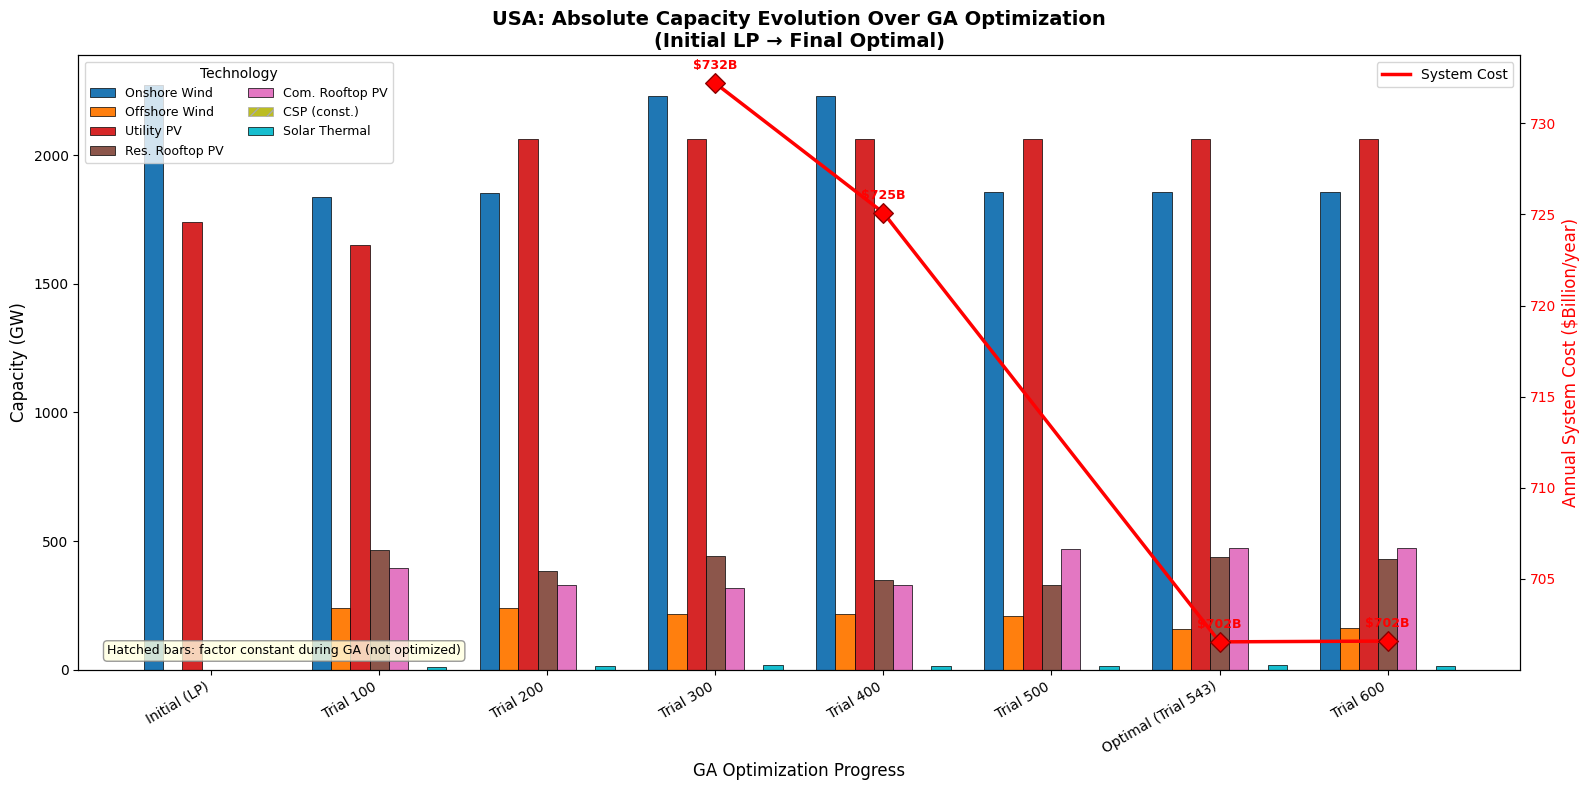

In [21]:
# Create the grouped bar chart with cost overlay
# X-axis: iterations/trials, bars grouped by technology, cost line overlay

fig, ax1 = plt.subplots(figsize=(16, 8))

n_trials = len(trial_indices)
x = np.arange(n_trials)  # Trial positions on x-axis
bar_width = 0.8 / n_techs
tech_colors = plt.cm.tab10(np.linspace(0, 1, n_techs))

# Plot bars for each technology across trials
bars_by_tech = []
for j, (tech_name, color) in enumerate(zip(tech_display_names, tech_colors)):
    offset = (j - n_techs / 2 + 0.5) * bar_width
    caps = [capacities_by_trial[i][j] for i in range(n_trials)]
    
    # Apply hatching if constant
    hatch = '//' if tech_name in constant_display_names else None
    edge = 'darkgray' if tech_name in constant_display_names else 'black'
    
    label_suffix = ' (const.)' if tech_name in constant_display_names else ''
    bars = ax1.bar(x + offset, caps, bar_width, label=f'{tech_name}{label_suffix}', 
                   color=color, edgecolor=edge, linewidth=0.5, hatch=hatch)
    bars_by_tech.append(bars)

ax1.set_xlabel('GA Optimization Progress', fontsize=12)
ax1.set_ylabel('Capacity (GW)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(labels_by_trial, rotation=30, ha='right', fontsize=10)
ax1.legend(loc='upper left', fontsize=9, ncol=2, title='Technology')
ax1.set_ylim(bottom=0)

# Add secondary axis for cost
ax2 = ax1.twinx()

# Plot cost as line with markers
valid_costs = [(i, c) for i, c in enumerate(costs_by_trial) if c is not None]
if valid_costs:
    cost_x = [i for i, _ in valid_costs]
    cost_y = [c for _, c in valid_costs]
    line, = ax2.plot(cost_x, cost_y, 'r-', linewidth=2.5, label='System Cost', zorder=10)
    markers = ax2.scatter(cost_x, cost_y, c='red', s=100, marker='D', zorder=11, edgecolors='darkred')
    
    # Add cost labels on the line
    for xi, yi in zip(cost_x, cost_y):
        ax2.annotate(f'${yi:.0f}B', (xi, yi), textcoords='offset points', 
                     xytext=(0, 10), ha='center', fontsize=9, color='red', fontweight='bold')
    
    ax2.set_ylabel('Annual System Cost ($Billion/year)', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right', fontsize=10)

# Add annotation for interpretation
ax1.annotate('Hatched bars: factor constant during GA (not optimized)', 
             xy=(0.02, 0.02), xycoords='axes fraction',
             fontsize=9, ha='left', va='bottom',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, edgecolor='gray'))

ax1.set_title('USA: Absolute Capacity Evolution Over GA Optimization\n(Initial LP → Final Optimal)', 
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Summary table of capacities and costs
import pandas as pd

summary_data = []
for i, (idx, label, caps, cost) in enumerate(zip(trial_indices, labels_by_trial, capacities_by_trial, costs_by_trial)):
    row = {"Trial": label, "Cost ($B/yr)": f"{cost:.1f}" if cost else "inf"}
    for j, tech in enumerate(tech_display_names):
        suffix = "*" if tech in constant_display_names else ""
        row[tech + suffix] = f"{caps[j]:.1f}"
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("Summary of Absolute Capacities (GW) at Key Iterations")
print("* = factor not optimized (constant during GA)")
print()
display(summary_df)

Summary of Absolute Capacities (GW) at Key Iterations
* = factor not optimized (constant during GA)



,Trial,Cost ($B/yr),Onshore Wind,Offshore Wind,Utility PV,Res. Rooftop PV,Com. Rooftop PV,CSP*,Solar Thermal
0,Initial (LP),inf,2274.0,0.0,1739.1,0.0,0.0,0.0,0.0
1,Trial 100,inf,1836.8,238.7,1651.3,464.5,395.4,0.0,11.8
2,Trial 200,inf,1853.7,239.1,2064.0,382.0,328.3,0.0,13.3
3,Trial 300,732.2,2228.2,218.5,2064.0,440.9,318.7,0.0,17.4
4,Trial 400,725.1,2228.2,218.5,2064.0,349.5,330.0,0.0,16.6
5,Trial 500,inf,1856.8,207.1,2064.0,330.6,468.1,0.0,14.5
6,Optimal (Trial 543),701.5,1856.8,158.8,2064.0,440.0,474.2,0.0,18.5
7,Trial 600,701.6,1856.8,163.8,2064.0,431.2,474.2,0.0,13.5


## Baseline vs GA-Optimized Comparison

Compare the previous (baseline) results with the GA-optimized solution, including:
- All generator capacities
- System cost
- Land area requirements

In [23]:
# Baseline (previous) results - before GA optimization
# All capacities in GW, land area in km², cost in $B/yr

BASELINE_RESULTS = {
    # Technology: (2050 Capacity GW, Install Density MW/km², Land Area km²)
    "Onshore Wind":         (1278.29443, 19.80198,  64553.86882),
    "Offshore Wind":        (468.35494,  7.19424,   65101.33720),
    "Residential PV":       (315.87399,  191.20459, 1652.02099),
    "Commercial PV":        (315.87399,  191.20459, 1652.02099),
    "Utility PV":           (2255.82324, 81.83306,  27566.16002),
    "CSP":                  (0.55991,    34.07155,  16.43336),
    "Geothermal Elec":      (6.52000,    303.95137, 21.45080),
    "Hydroelectric":        (86.66000,   1.99053,   43536.25080),
    "Wave":                 (1.65572,    30.30303,  54.63876),
    "Tidal":                (0.35000,    250.00000, 1.40000),
    "Solar Thermal":        (18.18500,   699.30070, 26.00455),
    "Geothermal Heat":      (20.71259,   303.95137, 68.14442),
    "Enhanced Geothermal":  (113.56408,  303.95137, 373.62584),
}

BASELINE_COST_BIL_YR = 728.79967  # Mean annual cost ($B/yr)
LAND_AREA_KM2 = 9147420.0  # Total land area of grid region

# Technologies that were optimized in the GA (have corresponding factors)
OPTIMIZED_TECHS = {"Onshore Wind", "Offshore Wind", "Residential PV", "Commercial PV", 
                   "Utility PV", "CSP", "Solar Thermal"}

# Technologies NOT optimized (constant or not in factor set)
NOT_OPTIMIZED_TECHS = {"Geothermal Elec", "Hydroelectric", "Wave", "Tidal", 
                       "Geothermal Heat", "Enhanced Geothermal"}

print(f"Baseline cost: ${BASELINE_COST_BIL_YR:.2f} billion/year")
print(f"Total land area: {LAND_AREA_KM2:,.0f} km²")

Baseline cost: $728.80 billion/year
Total land area: 9,147,420 km²


In [24]:
# Get the best feasible solution from GA optimization
best_feasible = [(i, r) for i, r in enumerate(records) 
                 if r.get("feasible", False) and r.get("cost_mn_bil_per_year", float("inf")) < float("inf")]
best_idx, best_record = min(best_feasible, key=lambda x: x[1]["cost_mn_bil_per_year"])

print(f"Best GA solution: Trial {best_idx} ({best_record['label']})")
print(f"Optimized cost: ${best_record['cost_mn_bil_per_year']:.2f} billion/year")
print(f"\nOptimized factors:")
for factor in FACTOR_TO_CAPACITY.keys():
    print(f"  {factor}: {best_record.get(factor, 0.0):.6f}")

# Calculate optimized capacities (GW) using factors × base capacities
# Map from our factor names to the baseline technology names
FACTOR_TO_BASELINE_TECH = {
    "faconwin": "Onshore Wind",
    "facoffwin": "Offshore Wind", 
    "facutilpv": "Utility PV",
    "facrespv": "Residential PV",
    "faccompv": "Commercial PV",
    "cspturbfac": "CSP",
    "facsht": "Solar Thermal",
}

# Compute optimized capacities
optimized_capacities_gw = {}
for factor_col, tech_name in FACTOR_TO_BASELINE_TECH.items():
    factor = best_record.get(factor_col, 0.0)
    base_key = FACTOR_TO_CAPACITY[factor_col][0]
    base_mw = BASE_CAPACITIES_USA[base_key]
    optimized_capacities_gw[tech_name] = factor * base_mw / 1000.0  # MW to GW

# For non-optimized technologies, use baseline values
for tech in NOT_OPTIMIZED_TECHS:
    optimized_capacities_gw[tech] = BASELINE_RESULTS[tech][0]

print(f"\nOptimized capacities (GW):")
for tech, cap in optimized_capacities_gw.items():
    baseline_cap = BASELINE_RESULTS[tech][0]
    change = (cap - baseline_cap) / baseline_cap * 100 if baseline_cap > 0 else 0
    opt_marker = "" if tech in NOT_OPTIMIZED_TECHS else " (optimized)"
    print(f"  {tech}: {cap:.2f} GW (baseline: {baseline_cap:.2f}, change: {change:+.1f}%){opt_marker}")

Best GA solution: Trial 543 (GA-gen44-ind7)
Optimized cost: $701.54 billion/year

Optimized factors:
  faconwin: 2.324101
  facoffwin: 0.301843
  facutilpv: 1.720100
  facrespv: 0.626884
  faccompv: 0.675582
  cspturbfac: 0.006008
  facsht: 1.015215

Optimized capacities (GW):
  Onshore Wind: 1856.80 GW (baseline: 1278.29, change: +45.3%) (optimized)
  Offshore Wind: 158.84 GW (baseline: 468.35, change: -66.1%) (optimized)
  Utility PV: 2063.96 GW (baseline: 2255.82, change: -8.5%) (optimized)
  Residential PV: 440.04 GW (baseline: 315.87, change: +39.3%) (optimized)
  Commercial PV: 474.22 GW (baseline: 315.87, change: +50.1%) (optimized)
  CSP: 0.01 GW (baseline: 0.56, change: -98.8%) (optimized)
  Solar Thermal: 18.46 GW (baseline: 18.18, change: +1.5%) (optimized)
  Hydroelectric: 86.66 GW (baseline: 86.66, change: +0.0%)
  Tidal: 0.35 GW (baseline: 0.35, change: +0.0%)
  Wave: 1.66 GW (baseline: 1.66, change: +0.0%)
  Enhanced Geothermal: 113.56 GW (baseline: 113.56, change: +0.0%

In [25]:
# Calculate land area requirements for optimized solution
# Land Area (km²) = Capacity (GW) * 1000 (MW/GW) / Install Density (MW/km²)

optimized_land_km2 = {}
baseline_land_km2 = {}

for tech, (baseline_cap, density, baseline_land) in BASELINE_RESULTS.items():
    baseline_land_km2[tech] = baseline_land
    opt_cap = optimized_capacities_gw[tech]
    # Calculate land area: capacity_MW / density_MW_per_km2
    optimized_land_km2[tech] = (opt_cap * 1000.0) / density if density > 0 else 0.0

# Total land areas
total_baseline_land = sum(baseline_land_km2.values())
total_optimized_land = sum(optimized_land_km2.values())

print("Land Area Comparison (km²):")
print(f"{'Technology':<22} {'Baseline':>12} {'Optimized':>12} {'Change':>10}")
print("-" * 60)
for tech in BASELINE_RESULTS.keys():
    b_land = baseline_land_km2[tech]
    o_land = optimized_land_km2[tech]
    change = o_land - b_land
    print(f"{tech:<22} {b_land:>12,.0f} {o_land:>12,.0f} {change:>+10,.0f}")
print("-" * 60)
print(f"{'TOTAL':<22} {total_baseline_land:>12,.0f} {total_optimized_land:>12,.0f} {total_optimized_land - total_baseline_land:>+10,.0f}")
print(f"\n% of Region Land Area: Baseline {100*total_baseline_land/LAND_AREA_KM2:.3f}%, Optimized {100*total_optimized_land/LAND_AREA_KM2:.3f}%")

Land Area Comparison (km²):
Technology                 Baseline    Optimized     Change
------------------------------------------------------------
Onshore Wind                 64,554       93,769    +29,215
Offshore Wind                65,101       22,079    -43,022
Residential PV                1,652        2,301       +649
Commercial PV                 1,652        2,480       +828
Utility PV                   27,566       25,222     -2,345
CSP                              16            0        -16
Geothermal Elec                  21           21         -0
Hydroelectric                43,536       43,536         -0
Wave                             55           55         +0
Tidal                             1            1         +0
Solar Thermal                    26           26         +0
Geothermal Heat                  68           68         +0
Enhanced Geothermal             374          374         -0
------------------------------------------------------------
TOTAL     

/var/folders/j2/nx0fvr356qz0ctgs_frxqz840000gn/T/ipykernel_98557/2900287569.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


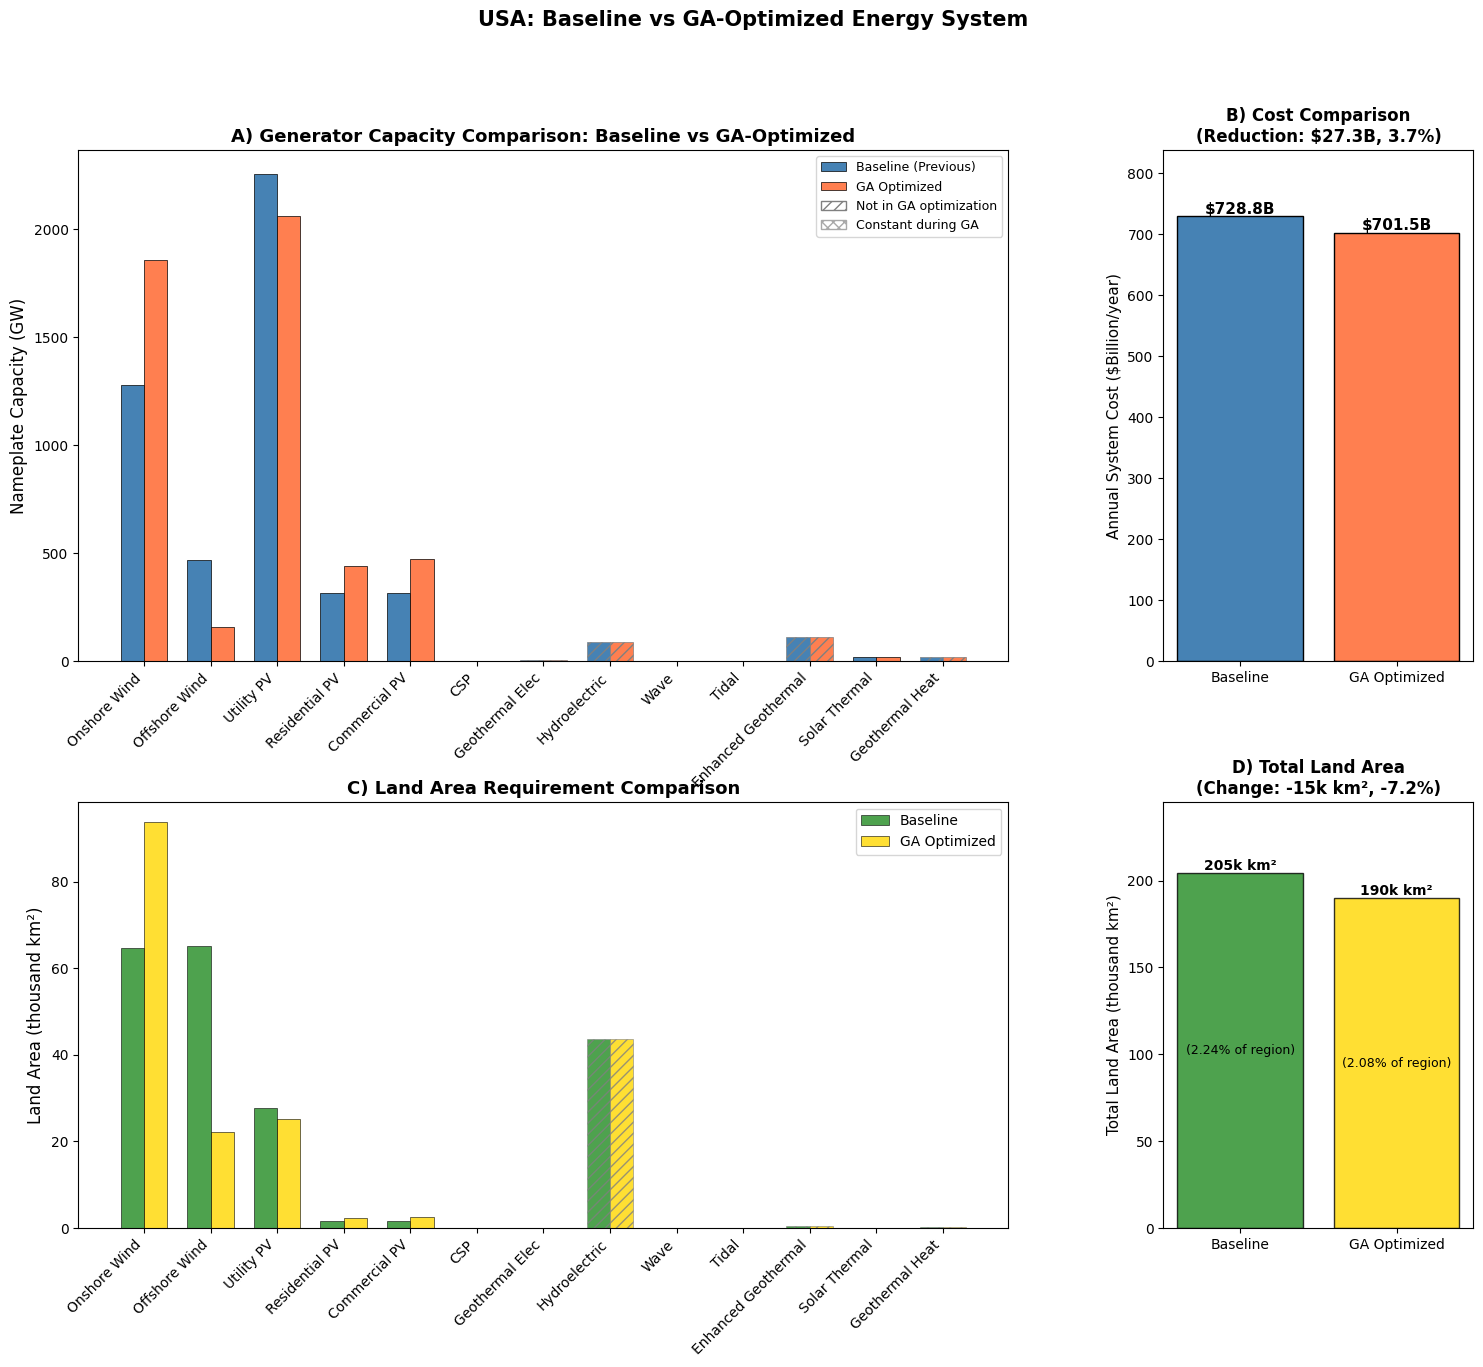


Figure saved to: data/results_verification/baseline_vs_optimized_comparison.png


In [26]:
# Create multi-panel figure: Capacity, Cost, and Land Area comparison
from matplotlib.patches import Patch

# Order technologies for plotting (electricity first, then heat)
tech_order = [
    "Onshore Wind", "Offshore Wind", "Utility PV", "Residential PV", "Commercial PV",
    "CSP", "Geothermal Elec", "Hydroelectric", "Wave", "Tidal", "Enhanced Geothermal",
    "Solar Thermal", "Geothermal Heat"
]

# Prepare data arrays
baseline_caps = [BASELINE_RESULTS[t][0] for t in tech_order]
optimized_caps = [optimized_capacities_gw[t] for t in tech_order]
baseline_lands = [baseline_land_km2[t] for t in tech_order]
optimized_lands = [optimized_land_km2[t] for t in tech_order]

# Identify which were optimized vs constant
was_optimized = [t in OPTIMIZED_TECHS for t in tech_order]
was_constant_in_ga = [t == "CSP" for t in tech_order]  # CSP factor was constant during GA

# Create figure with 3 panels
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1], width_ratios=[3, 1], hspace=0.3, wspace=0.25)

# Panel A: Capacity Comparison (main panel)
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(len(tech_order))
width = 0.35

bars1 = ax1.bar(x - width/2, baseline_caps, width, label='Baseline (Previous)', 
                color='steelblue', edgecolor='black', linewidth=0.5)
bars2 = ax1.bar(x + width/2, optimized_caps, width, label='GA Optimized', 
                color='coral', edgecolor='black', linewidth=0.5)

# Add hatching for non-optimized technologies
for i, (b1, b2, opt) in enumerate(zip(bars1, bars2, was_optimized)):
    if not opt:
        b1.set_hatch('///')
        b2.set_hatch('///')
        b1.set_edgecolor('gray')
        b2.set_edgecolor('gray')
    elif tech_order[i] == "CSP":
        # CSP was in factor set but constant during GA
        b2.set_hatch('xxx')
        b2.set_edgecolor('darkgray')

ax1.set_ylabel('Nameplate Capacity (GW)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(tech_order, rotation=45, ha='right', fontsize=10)
ax1.legend(loc='upper right', fontsize=10)
ax1.set_title('A) Generator Capacity Comparison: Baseline vs GA-Optimized', fontsize=13, fontweight='bold')
ax1.set_ylim(bottom=0)

# Add custom legend for hatching
legend_elements = [
    Patch(facecolor='white', edgecolor='gray', hatch='///', label='Not in GA optimization'),
    Patch(facecolor='white', edgecolor='darkgray', hatch='xxx', label='Constant during GA'),
]
ax1.legend(handles=ax1.get_legend_handles_labels()[0] + legend_elements, 
           loc='upper right', fontsize=9)

# Panel B: Cost Comparison (smaller panel)
ax2 = fig.add_subplot(gs[0, 1])
costs = [BASELINE_COST_BIL_YR, best_record['cost_mn_bil_per_year']]
cost_labels = ['Baseline', 'GA Optimized']
colors = ['steelblue', 'coral']
bars = ax2.bar(cost_labels, costs, color=colors, edgecolor='black', linewidth=1)

# Add value labels on bars
for bar, cost in zip(bars, costs):
    ax2.annotate(f'${cost:.1f}B', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

cost_reduction = BASELINE_COST_BIL_YR - best_record['cost_mn_bil_per_year']
cost_reduction_pct = 100 * cost_reduction / BASELINE_COST_BIL_YR
ax2.set_ylabel('Annual System Cost ($Billion/year)', fontsize=11)
ax2.set_title(f'B) Cost Comparison\n(Reduction: ${cost_reduction:.1f}B, {cost_reduction_pct:.1f}%)', 
              fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(costs) * 1.15)

# Panel C: Land Area Comparison
ax3 = fig.add_subplot(gs[1, 0])
bars3 = ax3.bar(x - width/2, np.array(baseline_lands)/1000, width, label='Baseline', 
                color='forestgreen', edgecolor='black', linewidth=0.5, alpha=0.8)
bars4 = ax3.bar(x + width/2, np.array(optimized_lands)/1000, width, label='GA Optimized', 
                color='gold', edgecolor='black', linewidth=0.5, alpha=0.8)

# Add hatching for non-optimized technologies
for i, (b3, b4, opt) in enumerate(zip(bars3, bars4, was_optimized)):
    if not opt:
        b3.set_hatch('///')
        b4.set_hatch('///')
        b3.set_edgecolor('gray')
        b4.set_edgecolor('gray')

ax3.set_ylabel('Land Area (thousand km²)', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(tech_order, rotation=45, ha='right', fontsize=10)
ax3.legend(loc='upper right', fontsize=10)
ax3.set_title('C) Land Area Requirement Comparison', fontsize=13, fontweight='bold')
ax3.set_ylim(bottom=0)

# Panel D: Total Land Area Summary
ax4 = fig.add_subplot(gs[1, 1])
total_lands = [total_baseline_land/1000, total_optimized_land/1000]
land_labels = ['Baseline', 'GA Optimized']
colors = ['forestgreen', 'gold']
bars = ax4.bar(land_labels, total_lands, color=colors, edgecolor='black', linewidth=1, alpha=0.8)

# Add value labels
for bar, land in zip(bars, total_lands):
    ax4.annotate(f'{land:.0f}k km²', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

land_change = total_optimized_land - total_baseline_land
land_change_pct = 100 * land_change / total_baseline_land
ax4.set_ylabel('Total Land Area (thousand km²)', fontsize=11)
sign = '+' if land_change > 0 else ''
ax4.set_title(f'D) Total Land Area\n(Change: {sign}{land_change/1000:.0f}k km², {sign}{land_change_pct:.1f}%)', 
              fontsize=12, fontweight='bold')
ax4.set_ylim(0, max(total_lands) * 1.2)

# Add % of region annotation
for i, (bar, land, total) in enumerate(zip(bars, total_lands, [total_baseline_land, total_optimized_land])):
    pct_region = 100 * total / LAND_AREA_KM2
    ax4.annotate(f'({pct_region:.2f}% of region)', (bar.get_x() + bar.get_width()/2, bar.get_height()/2),
                 ha='center', va='center', fontsize=9, color='black')

fig.suptitle('USA: Baseline vs GA-Optimized Energy System\n', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(repo_root / 'data/results_verification/baseline_vs_optimized_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: data/results_verification/baseline_vs_optimized_comparison.png")

In [27]:
# Summary table with all data
summary_comparison = []
for tech in tech_order:
    b_cap = BASELINE_RESULTS[tech][0]
    o_cap = optimized_capacities_gw[tech]
    cap_change = o_cap - b_cap
    cap_change_pct = 100 * cap_change / b_cap if b_cap > 0 else 0
    
    b_land = baseline_land_km2[tech]
    o_land = optimized_land_km2[tech]
    land_change = o_land - b_land
    
    opt_status = "Yes" if tech in OPTIMIZED_TECHS else "No"
    if tech == "CSP":
        opt_status = "Constant"
    
    summary_comparison.append({
        "Technology": tech,
        "Optimized?": opt_status,
        "Baseline Cap (GW)": f"{b_cap:.1f}",
        "GA Cap (GW)": f"{o_cap:.1f}",
        "Cap Change (%)": f"{cap_change_pct:+.1f}%",
        "Baseline Land (km²)": f"{b_land:,.0f}",
        "GA Land (km²)": f"{o_land:,.0f}",
        "Land Change (km²)": f"{land_change:+,.0f}",
    })

# Add totals row
summary_comparison.append({
    "Technology": "TOTAL",
    "Optimized?": "-",
    "Baseline Cap (GW)": f"{sum(baseline_caps):.1f}",
    "GA Cap (GW)": f"{sum(optimized_caps):.1f}",
    "Cap Change (%)": f"{100*(sum(optimized_caps)-sum(baseline_caps))/sum(baseline_caps):+.1f}%",
    "Baseline Land (km²)": f"{total_baseline_land:,.0f}",
    "GA Land (km²)": f"{total_optimized_land:,.0f}",
    "Land Change (km²)": f"{total_optimized_land - total_baseline_land:+,.0f}",
})

comparison_df = pd.DataFrame(summary_comparison)
print("=" * 100)
print("SUMMARY: Baseline vs GA-Optimized Comparison")
print("=" * 100)
print(f"\nCost: ${BASELINE_COST_BIL_YR:.2f}B → ${best_record['cost_mn_bil_per_year']:.2f}B " +
      f"(Reduction: ${cost_reduction:.2f}B, {cost_reduction_pct:.1f}%)")
print(f"Land: {total_baseline_land:,.0f} km² → {total_optimized_land:,.0f} km² " +
      f"(Change: {total_optimized_land - total_baseline_land:+,.0f} km², {land_change_pct:+.1f}%)")
print()
display(comparison_df)

SUMMARY: Baseline vs GA-Optimized Comparison

Cost: $728.80B → $701.54B (Reduction: $27.26B, 3.7%)
Land: 204,623 km² → 189,933 km² (Change: -14,691 km², -7.2%)



,Technology,Optimized?,Baseline Cap (GW),GA Cap (GW),Cap Change (%),Baseline Land (km²),GA Land (km²),Land Change (km²)
0,Onshore Wind,Yes,1278.3,1856.8,+45.3%,"64,554","93,769","+29,215"
1,Offshore Wind,Yes,468.4,158.8,-66.1%,"65,101","22,079","-43,022"
2,Utility PV,Yes,2255.8,2064.0,-8.5%,"27,566","25,222","-2,345"
3,Residential PV,Yes,315.9,440.0,+39.3%,"1,652","2,301",+649
4,Commercial PV,Yes,315.9,474.2,+50.1%,"1,652","2,480",+828
5,CSP,Constant,0.6,0.0,-98.8%,16,0,-16
6,Geothermal Elec,No,6.5,6.5,+0.0%,21,21,-0
7,Hydroelectric,No,86.7,86.7,+0.0%,"43,536","43,536",-0
8,Wave,No,1.7,1.7,+0.0%,55,55,+0
9,Tidal,No,0.3,0.3,+0.0%,1,1,+0
